CST MULTILAYER MODEL AS BUILT
--------------------------------------------------------------------------------------------
  f0 = 60 GHz    lambda0 = 4997 um    tee pitch = 200 um    ground width = 70 um
  gold  Kappa = 4.561e+07 S/m  ->  skin depth 304.2 nm,  Rs = 72.07 mOhm/sq  (lossy-metal SIBC, not a volume)
  stack vacuum 200 / LN SLAB_H / SiO2 BOX_H / Si 550 um, laterally INFINITE
  Si (lossy): eps 11.7, Kappa 2.5e-4 S/m      SetOpenBC_XY True, Multilayer True
  extraction: (gamma*L at N+1) - (gamma*L at N), N = 400 um, N+1 = 600 um
reference sweep: 498 geometries
  COMSOL 2D baseline   n_m 1.5095 - 2.1529   Z0 21.6 - 82.3 ohm   alpha 1.519 - 4.548 dB/cm
  multilayer delta     -1.072 to +17.221 dB/cm   (27 % of rows are RELIEF)
--------------------------------------------------------------------------------------------
 row  CST# |     WS    GAP    MTX     L1      L2     W1     W2 | a_unetch a_etched  delta_ML
 391   403 |  63.59   5.05  10.78    4.6    87.2    2.0   25.9 |    3.

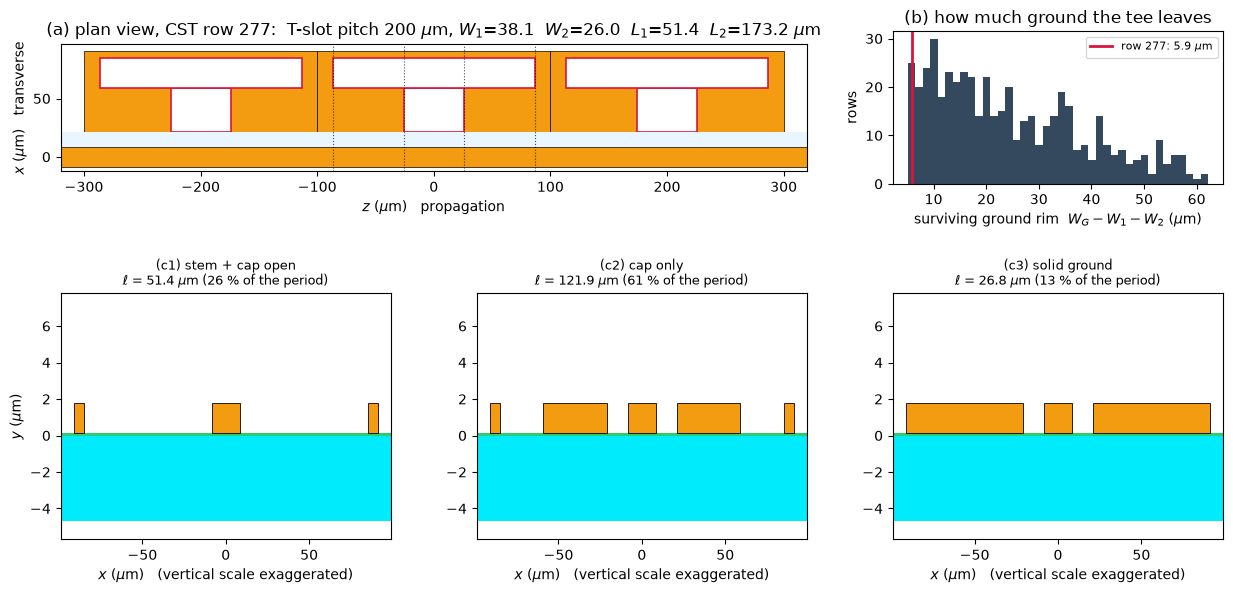

In [1]:
# %% [0] The etched unit cell -- CST parameter block, geometry, and mesher
#
# This notebook does NOT merge the 2D FEM baseline with the perturbation.  It
# answers two questions about the perturbation itself:
#   (1) why the composite  alpha = alpha_2D + [alpha_ML(etched) - alpha_ML(unetched)]
#       works -- i.e. which loss channels each half actually carries;
#   (2) whether that differential can be reproduced by a periodic unit cell in
#       code, and if not, what can.
import pathlib
import time
import warnings
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from shapely.affinity import scale as _scale
from shapely.geometry import MultiPolygon, Polygon, box
from shapely.ops import unary_union
from skfem import (Basis, BilinearForm, ElementTriP0, ElementTriP1, Functional,
                   InteriorFacetBasis, LinearForm, MeshTri, asm, condense, solve)
from skfem.helpers import dot, grad
from femwell.mesh import mesh_from_OrderedDict

warnings.filterwarnings("ignore")

C0, EPS0, MU0 = 299792458.0, 8.8541878128e-12, 4.0e-7 * np.pi
DB_PER_NEPER = 20.0 * np.log10(np.e)

# ============================================================
# 1. THE CST MULTILAYER MODEL, AS BUILT   (from the .mod history)
# ============================================================
F0      = 60.0e9      # Hz    the single extraction frequency
PITCH   = 200.0       # um    tee pitch; N = 400 um (2 pairs), N+1 = 600 um (3 pairs)
WG      = 70.0        # um    ground electrode width  (frozen, = aul_w of the 2D model)
SLOT_TH = None        # the tee is cut through the FULL metal thickness, Zrange -MTX..0

# Layer stack, CST "LayerStacking", normal z, laterally INFINITE:
#   1  200 um   Vacuum
#   2  SLAB_H   LITHIUM NIOBATE   anisotropic (43, 28, 43)
#   3  BOX_H    SIO2              eps 3.9
#   4  550 um   Silicon (lossy)   eps 11.7 (11.9 in the library card), Kappa 2.5e-4
# Gold: Type "Lossy metal", Sigma 4.561e7  -> surface-impedance BC, not a volume
# Solver: HF Multilayer, Surface / General purpose, OrderSrf First, AccuracySrf 1e-3,
#         SetOpenBC_XY True, Multilayer True, mesh 5 um (2 um on the electrodes).
SIGMA_AU = 4.561e7
SKIN_AU  = np.sqrt(2.0 / (2 * np.pi * F0 * MU0 * SIGMA_AU))
RS_AU    = 1.0 / (SIGMA_AU * SKIN_AU)                       # ohm/square

BOX_H, SI_H, TFLN, WG_TOP, THETA, CAP_H = 4.7, 550.0, 0.46, 0.8, 60.0, 1.4

EPS = {"LN": (28.0, 44.0), "SiO2": (3.9, 3.9), "Si": (11.7, 11.7),
       "air": (1.0, 1.0), "Au": (1.0, 1.0)}
COL = {"LN": "#2ecc71", "SiO2": "#00ebfc", "Si": "#7f8c8d",
       "air": "#ffffff", "Au": "#f39c12"}

# ============================================================
# 2. THE 500-GEOMETRY MULTILAYER REFERENCE
# ============================================================
# Columns: the 8 CST DOFs, the COMSOL 2D baseline (n_m, Z0, alpha), and the three
# multilayer numbers produced by the N+1 - N differential extraction:
#   alpha_ML_unetched = ((gL_u,N+1 - gL_u,N)/0.02) * 8.686      [dB/cm]
#   alpha_ML_etched   = ((gL_e,N+1 - gL_e,N)/0.02) * 8.686      [dB/cm]
#   delta_ML          = alpha_ML_etched - alpha_ML_unetched     <- THE PERTURBATION
def _find(name, where="data"):
    """Locate a data file whether the kernel was started in the repo root, in
    notebooks/, or anywhere above either."""
    here = pathlib.Path.cwd().resolve()
    for base in [here, *here.parents]:
        for cand in (base / where / name, base / "notebooks" / where / name):
            if cand.is_file():
                return cand
    raise FileNotFoundError(
        f"{where}/{name} not found. It ships with the repo next to this notebook; "
        f"start the kernel in the repo root or in notebooks/, or edit this line.")


REF = pd.read_csv(_find("cst_multilayer_500.csv"))

# Five rows that span the whole perturbation range, from strongest relief to the
# single worst penalty in the sweep.  Everything below is run on these.
DEMO = [391, 210, 36, 250, 58]


def geom_of(i):
    r = REF.iloc[i]
    return dict(idx=i, cst=int(r.Index), WS=r.WS, GAP=r.GAP, MTX=r.MTX,
                cap_w=r.cap_w, wg_h=r.ETCH_DEPTH, L1=r.L1, L2=r.L2, W1=r.W1, W2=r.W2,
                n_m=r.n_m_COMSOL, Z0=r.Z0_COMSOL, a_C=r.alpha_COMSOL,
                a_u=r.alpha_ML_unetched, a_e=r.alpha_ML_etched, d=r.delta_ML)


# ============================================================
# 3. THE T-SLOT AND THE z-SECTIONS IT CUTS THE PERIOD INTO
# ============================================================
# CST builds the slot as two bricks, both cut through the full metal thickness:
#   stem  Yrange 0..W1          from the ground INNER edge outwards, Zrange -L1/2..L1/2
#   cap   Yrange W1..W1+W2      just outside it,                    Zrange -L2/2..L2/2
# so one period contains at most three distinct uniform cross-sections.
def tee_sections(WS, GAP, W1, W2, L1, L2, p=PITCH, wg=WG):
    x_gi = WS / 2.0 + GAP
    x_go = x_gi + wg
    a, b, c = x_gi, min(x_gi + W1, x_go), min(x_gi + W1 + W2, x_go)
    lo, hi = min(L1, L2), max(L1, L2)
    out = [(lo,      [(c, x_go)],              "stem + cap open"),
           (hi - lo, [(a, b), (c, x_go)] if L2 >= L1 else [(b, x_go)],
                     "cap only" if L2 >= L1 else "stem only"),
           (p - hi,  [(x_gi, x_go)],           "solid ground")]
    return [(ln, sp, nm) for ln, sp, nm in out if ln > 1e-9]


# ============================================================
# 4. CROSS-SECTION MESHER  (the cell [0] mesher of the 2D notebook, generalised
#    to an arbitrary list of ground strips so a slotted section can be meshed)
# ============================================================
MIN_AREA = 2.0e-4


def _mirror(p):
    return _scale(p, xfact=-1.0, yfact=1.0, origin=(0, 0))


def _clean(g):
    """Drop slivers.  gmsh snaps their vertices together and then cannot close
    the curve loop, which surfaces as an opaque IndexError deep inside pygmsh."""
    if g.is_empty or g.area < MIN_AREA:
        return None
    if not g.interiors and g.length > 0.0 and 4.0 * g.area / g.length < 8.0e-3:
        return None
    return g


def _as_geom(geom):
    """Sanitised Polygon / MultiPolygon.  Pieces are never handed over one by one:
    femwell fragments a MultiPolygon itself, and splitting it into an entry per
    piece makes its boolean pass hand gmsh empty shapes."""
    if geom.is_empty:
        return None
    try:
        geom = geom.buffer(0)
    except Exception:
        pass
    parts = list(geom.geoms) if hasattr(geom, "geoms") else [geom]
    keep = [c for c in (_clean(g) for g in parts
                        if getattr(g, "geom_type", "") == "Polygon") if c is not None]
    if not keep:
        return None
    return keep[0] if len(keep) == 1 else MultiPolygon(keep)


def wall_pitch(wall_x, fallback):
    sx = np.sort(np.unique(np.round(np.asarray(wall_x, float), 9)))
    return float(np.min(np.diff(sx))) if sx.size > 1 else fallback


def build2d(WS, GAP, MTX, cap_w, wg_h, ground_spans=None, *, wg=WG, lat_pad=200.0,
            si_h=SI_H, air_h=550.0, corner_box=0.25, corner_res=0.10, skin_t=0.10,
            skin_reach=5.0, skin_res=0.20, mf=2.0, min_pitch=None):
    slab_h = TFLN - wg_h
    basetta = wg_h / np.tan(np.deg2rad(THETA))
    wg_bottom = WG_TOP + 2.0 * basetta
    x_sig, x_gi = WS / 2.0, WS / 2.0 + GAP
    x_go = x_gi + wg
    x_dom = x_go + lat_pad
    x_wg = x_sig + GAP / 2.0
    y_el, y_rib = slab_h + MTX, slab_h + wg_h
    spans = [(a, b) for a, b in (ground_spans or [(x_gi, x_go)]) if b - a > 1e-9]

    def rib(xc):
        return Polygon([(xc - wg_bottom / 2, slab_h), (xc - WG_TOP / 2, y_rib),
                        (xc + WG_TOP / 2, y_rib), (xc + wg_bottom / 2, slab_h)])

    rib_r = rib(x_wg); rib_l = _mirror(rib_r)
    cap_r = box(x_wg - cap_w / 2, slab_h, x_wg + cap_w / 2,
                slab_h + CAP_H).difference(rib_r)
    cap_l = _mirror(cap_r)
    el_sig = box(-x_sig, slab_h, x_sig, y_el)
    gnd_r = [box(a, slab_h, b, y_el) for a, b in spans]
    gnd_l = [_mirror(g) for g in gnd_r]
    solids = unary_union([el_sig] + gnd_r + gnd_l + [cap_r, cap_l, rib_r, rib_l])

    # every vertical metal wall carries the r^(-1/3) surface-charge singularity,
    # so every one of them -- the slot rims included -- gets its own corner box
    wall_x = [-x_sig, x_sig]
    for a, b in spans:
        wall_x += [a, b, -a, -b]
    if min_pitch is None:
        min_pitch = wall_pitch(wall_x, 2 * skin_reach)
    # keep the collars from welding across a narrow slot or a narrow surviving strip
    skin_t = min(skin_t, 0.30 * min_pitch)
    skin_reach = min(skin_reach, 0.40 * min_pitch)
    corner_box = min(corner_box, 0.30 * min_pitch)

    corners = [box(xc - corner_box, yc - corner_box, xc + corner_box, yc + corner_box)
               for xc in wall_x for yc in (slab_h, y_el)]
    corner_ring = unary_union(corners).difference(solids)
    walls = []
    for xc in wall_x:
        walls.append(box(xc - skin_t, slab_h, xc + skin_t, y_el))
        walls.append(box(xc - skin_reach, y_el, xc + skin_reach, y_el + skin_t))
        walls.append(box(xc - skin_reach, slab_h - skin_t, xc + skin_reach, slab_h))
    skin_ring = unary_union(walls).difference(unary_union([solids, corner_ring]))

    cut = unary_union([solids, corner_ring, skin_ring])
    air_gap = box(-x_go - 2.0, slab_h, x_go + 2.0, slab_h + MTX + 4.0).difference(cut)
    air_near = box(-x_go - 15.0, slab_h, x_go + 15.0, slab_h + MTX + 15.0).difference(
        unary_union([cut, air_gap]))
    air_far = box(-x_dom, slab_h, x_dom, slab_h + air_h).difference(
        unary_union([cut, air_gap, air_near]))
    slab_near = box(-x_go - 15.0, 0.0, x_go + 15.0, slab_h).difference(
        unary_union([corner_ring, skin_ring]))
    slab_far = box(-x_dom, 0.0, x_dom, slab_h).difference(slab_near)
    box_near = box(-x_go - 15.0, -BOX_H, x_go + 15.0, 0.0)
    box_far = box(-x_dom, -BOX_H, x_dom, 0.0).difference(box_near)
    si = box(-x_dom, -BOX_H - si_h, x_dom, -BOX_H)

    polys, r2m, res, dist = OrderedDict(), {}, {}, {}

    def put(name, geom, material, resolution, distance):
        g = _as_geom(geom)
        if g is not None:
            polys[name] = g; r2m[name] = material
            res[name] = resolution; dist[name] = distance

    put("corner_ring", corner_ring, "air", corner_res, 0.6)
    put("skin_ring", skin_ring, "air", skin_res, 1.0)
    put("cap_r", cap_r, "SiO2", 0.20, 1.0); put("cap_l", cap_l, "SiO2", 0.20, 1.0)
    put("rib_r", rib_r, "LN", 0.12, 1.0); put("rib_l", rib_l, "LN", 0.12, 1.0)
    put("el_sig", el_sig, "Au", 0.80, 3.0)
    put("el_gr", unary_union(gnd_r), "Au", 0.80, 3.0)
    put("el_gl", unary_union(gnd_l), "Au", 0.80, 3.0)
    put("air_gap", air_gap, "air", 0.30, 3.0)
    put("slab_near", slab_near, "LN", 0.25, 3.0)
    put("air_near", air_near, "air", 2.0, 10.0)
    put("box_near", box_near, "SiO2", 2.0, 5.0)
    put("slab_far", slab_far, "LN", 6.0, 10.0)
    put("box_far", box_far, "SiO2", 6.0, 10.0)
    put("si", si, "Si", 30.0, 30.0)
    put("air_far", air_far, "air", 30.0, 30.0)

    resolutions = {k: {"resolution": res[k] * (1.0 if k in ("corner_ring", "skin_ring")
                                               else mf), "distance": dist[k]}
                   for k in polys}
    raw = mesh_from_OrderedDict(polys, resolutions=resolutions,
                                default_resolution_min=0.4 * min(corner_res, skin_res),
                                default_resolution_max=35.0)
    mesh = MeshTri(raw.points[:, :2].T, raw.cells_dict["triangle"].T)
    sub = raw.cell_data_dict["gmsh:physical"]["triangle"]
    n2i = {n: (d[0] if hasattr(d, "__getitem__") else d) for n, d in raw.field_data.items()}
    region = np.empty(mesh.nelements, dtype=object)
    for rn, sid in n2i.items():
        bn = rn.split("___")[0]
        if bn in polys:
            region[sub == sid] = bn
    region = region.astype(str)
    mat = np.array([r2m[r] for r in region], dtype=object)
    coll = np.isin(region, ("corner_ring", "skin_ring"))
    if coll.any():
        yc = mesh.p[1, mesh.t].mean(axis=0)
        mat[coll] = np.where(yc < 0.0, "SiO2", np.where(yc < slab_h, "LN", "air"))[coll]
    return dict(mesh=mesh, region=region, mat=mat,
                is_metal=np.array([r2m[r] == "Au" for r in region]),
                is_sig=region == "el_sig", spans=spans, slab_h=slab_h,
                x_sig=x_sig, x_gi=x_gi, x_go=x_go, y_el=y_el, min_pitch=min_pitch)


# ---- report -----------------------------------------------------------------
print("=" * 92)
print("CST MULTILAYER MODEL AS BUILT")
print("-" * 92)
print(f"  f0 = {F0/1e9:.0f} GHz    lambda0 = {C0/F0*1e6:.0f} um    tee pitch = {PITCH:.0f} um"
      f"    ground width = {WG:.0f} um")
print(f"  gold  Kappa = {SIGMA_AU:.4g} S/m  ->  skin depth {SKIN_AU*1e9:.1f} nm,"
      f"  Rs = {RS_AU*1e3:.2f} mOhm/sq  (lossy-metal SIBC, not a volume)")
print( "  stack vacuum 200 / LN SLAB_H / SiO2 BOX_H / Si 550 um, laterally INFINITE")
print( "  Si (lossy): eps 11.7, Kappa 2.5e-4 S/m      SetOpenBC_XY True, Multilayer True")
print( "  extraction: (gamma*L at N+1) - (gamma*L at N), N = 400 um, N+1 = 600 um")
print("=" * 92)
print(f"reference sweep: {len(REF)} geometries")
print(f"  COMSOL 2D baseline   n_m {REF.n_m_COMSOL.min():.4f} - {REF.n_m_COMSOL.max():.4f}"
      f"   Z0 {REF.Z0_COMSOL.min():.1f} - {REF.Z0_COMSOL.max():.1f} ohm"
      f"   alpha {REF.alpha_COMSOL.min():.3f} - {REF.alpha_COMSOL.max():.3f} dB/cm")
print(f"  multilayer delta     {REF.delta_ML.min():+.3f} to {REF.delta_ML.max():+.3f} dB/cm"
      f"   ({(REF.delta_ML < 0).mean()*100:.0f} % of rows are RELIEF)")
print("-" * 92)
print(f"{'row':>4} {'CST#':>5} | {'WS':>6} {'GAP':>6} {'MTX':>6} {'L1':>6} {'L2':>7} "
      f"{'W1':>6} {'W2':>6} | {'a_unetch':>8} {'a_etched':>8} {'delta_ML':>9}")
for i in DEMO:
    g = geom_of(i)
    print(f"{i:>4} {g['cst']:>5} | {g['WS']:>6.2f} {g['GAP']:>6.2f} {g['MTX']:>6.2f} "
          f"{g['L1']:>6.1f} {g['L2']:>7.1f} {g['W1']:>6.1f} {g['W2']:>6.1f} | "
          f"{g['a_u']:>8.3f} {g['a_e']:>8.3f} {g['d']:>+9.3f}")
print("=" * 92)

# ---- geometry preview -------------------------------------------------------
SHOW = DEMO[-1]                                   # the worst-case row
gg = geom_of(SHOW)
secs = tee_sections(gg["WS"], gg["GAP"], gg["W1"], gg["W2"], gg["L1"], gg["L2"])
x_gi = gg["WS"] / 2 + gg["GAP"]; x_go = x_gi + WG

fig = plt.figure(figsize=(15.0, 6.6))
gs = fig.add_gridspec(2, 3, height_ratios=[0.62, 1.0], hspace=0.55, wspace=0.26)

# (a) plan view of one and a half periods of the right-hand ground
ax = fig.add_subplot(gs[0, :2])
for k in (-1, 0, 1):
    z0 = k * PITCH
    ax.add_patch(Rectangle((z0 - PITCH / 2, x_gi), PITCH, WG, fc=COL["Au"],
                           ec="k", lw=0.5))
    ax.add_patch(Rectangle((z0 - gg["L1"] / 2, x_gi), gg["L1"], gg["W1"],
                           fc="w", ec="crimson", lw=1.2))
    ax.add_patch(Rectangle((z0 - gg["L2"] / 2, x_gi + gg["W1"]), gg["L2"], gg["W2"],
                           fc="w", ec="crimson", lw=1.2))
ax.add_patch(Rectangle((-1.6 * PITCH, gg["WS"] / 2), 3.2 * PITCH, gg["GAP"],
                       fc="#eaf6ff", ec="none"))
ax.add_patch(Rectangle((-1.6 * PITCH, -gg["WS"] / 2), 3.2 * PITCH, gg["WS"],
                       fc=COL["Au"], ec="k", lw=0.5))
# section boundaries within the central period
for zb in (gg["L1"] / 2, gg["L2"] / 2):
    for s_ in (-1, 1):
        ax.axvline(s_ * zb, color="k", ls=":", lw=0.8, alpha=0.7)
ax.set_xlim(-1.6 * PITCH, 1.6 * PITCH); ax.set_ylim(-gg["WS"] / 2 - 4, x_go + 6)
ax.set_xlabel(r"$z$ ($\mu$m)   propagation"); ax.set_ylabel(r"$x$ ($\mu$m)   transverse")
ax.set_title(f"(a) plan view, CST row {gg['cst']}:  T-slot pitch {PITCH:.0f} $\\mu$m, "
             f"$W_1$={gg['W1']:.1f}  $W_2$={gg['W2']:.1f}  "
             f"$L_1$={gg['L1']:.1f}  $L_2$={gg['L2']:.1f} $\\mu$m")
ax.set_aspect("equal")

# (b) the surviving ground bridge, the quantity that governs the return path
ax = fig.add_subplot(gs[0, 2])
left = WG - REF.W1 - REF.W2
ax.hist(left, bins=40, color="#34495e")
ax.axvline(WG - gg["W1"] - gg["W2"], color="crimson", lw=2,
           label=f"row {gg['cst']}: {WG-gg['W1']-gg['W2']:.1f} $\\mu$m")
ax.set_xlabel(r"surviving ground rim  $W_G-W_1-W_2$ ($\mu$m)")
ax.set_ylabel("rows"); ax.legend(fontsize=8)
ax.set_title("(b) how much ground the tee leaves")

# (c) the three cross-sections
for j, (ln, sp, nm) in enumerate(secs):
    ax = fig.add_subplot(gs[1, j])
    slab_h = TFLN - gg["wg_h"]; y_el = slab_h + gg["MTX"]
    ax.add_patch(Rectangle((-x_go - 10, -BOX_H), 2 * (x_go + 10), BOX_H,
                           fc=COL["SiO2"], ec="none"))
    ax.add_patch(Rectangle((-x_go - 10, 0), 2 * (x_go + 10), slab_h,
                           fc=COL["LN"], ec="none"))
    ax.add_patch(Rectangle((-gg["WS"] / 2, slab_h), gg["WS"], gg["MTX"],
                           fc=COL["Au"], ec="k", lw=0.6))
    for a, b in sp:
        for s in (1, -1):
            ax.add_patch(Rectangle((s * a if s > 0 else -b, slab_h), b - a, gg["MTX"],
                                   fc=COL["Au"], ec="k", lw=0.6))
    ax.set_xlim(-x_go - 8, x_go + 8); ax.set_ylim(-BOX_H - 1, y_el + 6)
    ax.set_xlabel(r"$x$ ($\mu$m)   (vertical scale exaggerated)")
    if j == 0:
        ax.set_ylabel(r"$y$ ($\mu$m)")
    ax.set_title(f"(c{j+1}) {nm}\n$\\ell$ = {ln:.1f} $\\mu$m "
                 f"({100*ln/PITCH:.0f} % of the period)", fontsize=9)
plt.show()


BACKGROUND WAVES THE LAYER STACK CAN CARRY AT 60 GHz
--------------------------------------------------------------------------------------------
  Si slab 550 um, V = k0 (d/2) sqrt(eps-1) = 1.1312 rad  ->  one TE and one TM bound mode
  TE surface waves : [2.5414]
  TM surface waves : [1.1507]
  free space       : 1.0000
--------------------------------------------------------------------------------------------
  CPW mode index over the 498 rows : 1.5095 .. 2.1529
  a background wave carries power away when  n_bg > n_CPW:
     free space  n=1.0000  <  n_CPW   ->  CLOSED, no space-wave radiation
     TM0         n=1.1507  <  n_CPW   ->  CLOSED
     TE0         n=2.5414  >  n_CPW   ->  *** OPEN for every row ***
--------------------------------------------------------------------------------------------
  grating lobe (m = -1) would need p > 1064 um;  pitch is 200 um   -> every harmonic but m = 0 is evanescent
  Bragg stop band would need p > 1160 um  -> far away
  beta_0 p = 0.541 rad

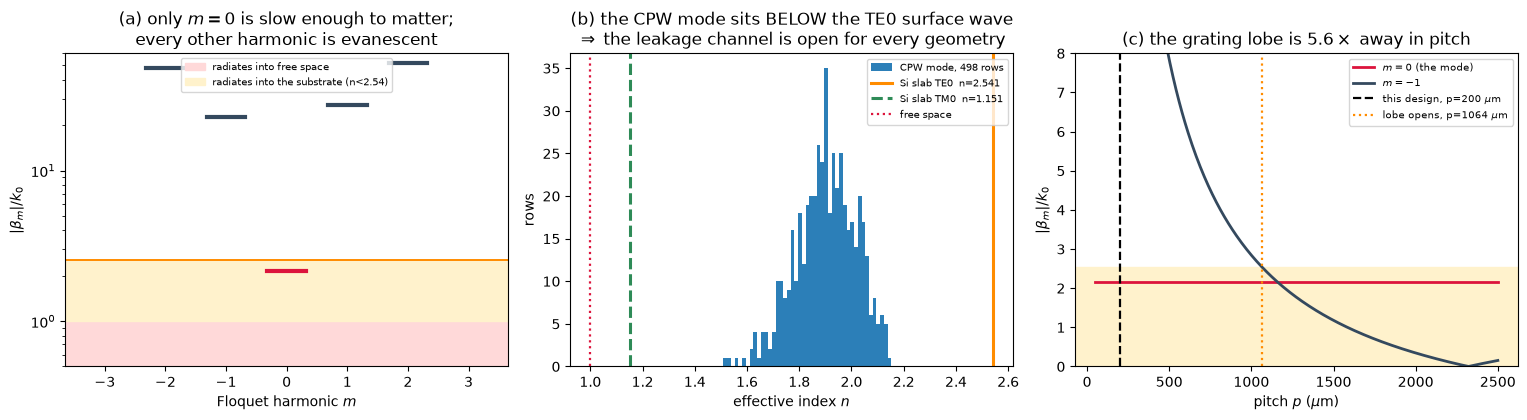

In [2]:
# %% [1] Where the periodic line sits in wavenumber space
#
# Before asking a solver anything, settle by inspection which loss channels are
# even OPEN for this structure at 60 GHz.  Two separate questions:
#   (i)  can a Floquet space harmonic of the 200 um period radiate?  (grating lobe)
#   (ii) is the n = 0 mode itself above the light line of a background wave the
#        stack can carry?  (leakage / leaky-wave)
from scipy.optimize import brentq

k0 = 2.0 * np.pi * F0 / C0 * 1e-6                      # rad/um

# ---- background waves of the laterally infinite stack ----------------------
# Transfer matrix for air | LN | SiO2 | Si | air.  A guided surface wave is a
# pole: the coefficient of the incoming wave in the bottom half-space vanishes.
STACK = [(1.0, np.inf), (34.7, TFLN), (3.9, BOX_H), (11.7, SI_H), (1.0, np.inf)]


def stack_det(neff, pol):
    kz = [np.sqrt(complex(e) * k0 ** 2 - (neff * k0) ** 2) for e, _ in STACK]
    M = np.eye(2, dtype=complex)
    for i in range(len(STACK) - 1):
        e1, e2 = STACK[i][0], STACK[i + 1][0]
        r = (kz[i] / kz[i + 1]) if pol == "TE" else (kz[i] * e2) / (kz[i + 1] * e1)
        M = M @ (0.5 * np.array([[1 + r, 1 - r], [1 - r, 1 + r]], dtype=complex))
        if i + 1 < len(STACK) - 1:
            ph = kz[i + 1] * STACK[i + 1][1]
            M = M @ np.array([[np.exp(-1j * ph), 0], [0, np.exp(1j * ph)]])
    return M[0, 0]


def stack_modes(pol, n=6000):
    ns = np.linspace(1.0005, np.sqrt(11.7) - 1e-4, n)
    v = np.abs([stack_det(x, pol) for x in ns])
    out = []
    for i in range(1, n - 1):
        if v[i] < v[i - 1] and v[i] < v[i + 1] and v[i] < 0.1 * v.max():
            lo, hi = ns[i - 1], ns[i + 1]
            f = lambda x: stack_det(x, pol).real
            try:
                out.append(brentq(f, lo, hi, xtol=1e-11) if f(lo) * f(hi) < 0 else ns[i])
            except Exception:
                out.append(ns[i])
    return out



n_TE = stack_modes("TE"); n_TM = stack_modes("TM")
n_sub = max(n_TE + n_TM)
n_lo, n_hi = REF.n_m_COMSOL.min(), REF.n_m_COMSOL.max()

# ---- grating-lobe onset ----------------------------------------------------
# harmonic m radiates into a background of index n_bg when |beta_0 + 2 pi m / p|
# < k0 n_bg.  The m = -1 lobe is the first to open, at
#         p_lobe = lambda0 / (n_m + n_bg)
p_lobe = (C0 / F0 * 1e6) / (n_hi + n_sub)
p_bragg = (C0 / F0 * 1e6) / (2.0 * n_hi)

print("=" * 92)
print("BACKGROUND WAVES THE LAYER STACK CAN CARRY AT 60 GHz")
print("-" * 92)
print(f"  Si slab 550 um, V = k0 (d/2) sqrt(eps-1) = "
      f"{k0*SI_H/2*np.sqrt(11.7-1):.4f} rad  ->  one TE and one TM bound mode")
print(f"  TE surface waves : {[round(x,4) for x in n_TE]}")
print(f"  TM surface waves : {[round(x,4) for x in n_TM]}")
print(f"  free space       : 1.0000")
print("-" * 92)
print(f"  CPW mode index over the 498 rows : {n_lo:.4f} .. {n_hi:.4f}")
print(f"  a background wave carries power away when  n_bg > n_CPW:")
print(f"     free space  n=1.0000  <  n_CPW   ->  CLOSED, no space-wave radiation")
print(f"     TM0         n={n_TM[0]:.4f}  <  n_CPW   ->  CLOSED")
print(f"     TE0         n={n_TE[0]:.4f}  >  n_CPW   ->  *** OPEN for every row ***")
print("-" * 92)
print(f"  grating lobe (m = -1) would need p > {p_lobe:.0f} um;  pitch is {PITCH:.0f} um"
      f"   -> every harmonic but m = 0 is evanescent")
print(f"  Bragg stop band would need p > {p_bragg:.0f} um  -> far away")
print(f"  beta_0 p = {k0*n_hi*PITCH:.3f} rad, p/lambda_g = {PITCH*n_hi/(C0/F0*1e6):.4f}"
      f"   -> the period is deeply sub-wavelength and the line HOMOGENISES")
print("=" * 92)
print("So the only radiative channel open to this structure is leakage of the")
print("m = 0 mode into the TE0 surface wave of the 550 um silicon substrate.")
print("A uniform line couples to it negligibly -- the aperture is lambda0/170 wide")
print("and the ground planes shield it.  A T-slot cut through the ground is an")
print("aperture up to 65 x 190 um that opens straight onto the hot gap field.")
print("=" * 92)

# ---- figure ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15.4, 4.3))

ax = axes[0]
ms = np.arange(-3, 4)
b0 = k0 * n_hi
for m in ms:
    bm = (b0 + 2 * np.pi * m / PITCH) / k0
    ax.plot([m - 0.32, m + 0.32], [abs(bm)] * 2, lw=3,
            color="crimson" if m == 0 else "#34495e")
ax.axhspan(0, 1.0, color="#ffd9d9", label="radiates into free space")
ax.axhspan(1.0, n_sub, color="#fff2cc", label=f"radiates into the substrate (n<{n_sub:.2f})")
ax.axhline(n_sub, color="darkorange", lw=1.4)
ax.set_yscale("log"); ax.set_ylim(0.5, 60)
ax.set_xlabel("Floquet harmonic $m$"); ax.set_ylabel(r"$|\beta_m|/k_0$")
ax.set_title("(a) only $m=0$ is slow enough to matter;\nevery other harmonic is evanescent")
ax.legend(fontsize=7, loc="upper center")

ax = axes[1]
ax.hist(REF.n_m_COMSOL, bins=45, color="#2c7fb8", label="CPW mode, 498 rows")
ax.axvline(n_TE[0], color="darkorange", lw=2.2, label=f"Si slab TE0  n={n_TE[0]:.3f}")
ax.axvline(n_TM[0], color="seagreen", lw=2.2, ls="--", label=f"Si slab TM0  n={n_TM[0]:.3f}")
ax.axvline(1.0, color="crimson", lw=1.6, ls=":", label="free space")
ax.set_xlabel(r"effective index $n$"); ax.set_ylabel("rows")
ax.set_title("(b) the CPW mode sits BELOW the TE0 surface wave\n"
             "$\\Rightarrow$ the leakage channel is open for every geometry")
ax.legend(fontsize=7.5)

ax = axes[2]
pp = np.linspace(50, 2500, 400)
ax.plot(pp, np.full_like(pp, n_hi), color="crimson", lw=2, label="$m=0$ (the mode)")
ax.plot(pp, np.abs(n_hi - (C0 / F0 * 1e6) / pp), color="#34495e", lw=2,
        label="$m=-1$")
ax.axhspan(0, n_sub, color="#fff2cc")
ax.axvline(PITCH, color="k", lw=1.6, ls="--", label=f"this design, p={PITCH:.0f} $\\mu$m")
ax.axvline(p_lobe, color="darkorange", lw=1.6, ls=":",
           label=f"lobe opens, p={p_lobe:.0f} $\\mu$m")
ax.set_xlabel(r"pitch $p$ ($\mu$m)"); ax.set_ylabel(r"$|\beta_m|/k_0$")
ax.set_ylim(0, 8); ax.set_title("(c) the grating lobe is $5.6\\times$ away in pitch")
ax.legend(fontsize=7.5)
plt.tight_layout(); plt.show()


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


...

Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


orthogonality: run the SAME cell with the tee removed -> d_cell = +0.000e+00 dB/cm
   the cell collapses onto its own unetched reference identically, so the
   perturbation it produces cannot double count anything in the 2D baseline

5 unit cells in 99.3 s
VERDICT: the quasi-static cell tracks the RELIEF branch and produces no
penalty branch at all.  It is additive and orthogonal, but it is not 1:1.


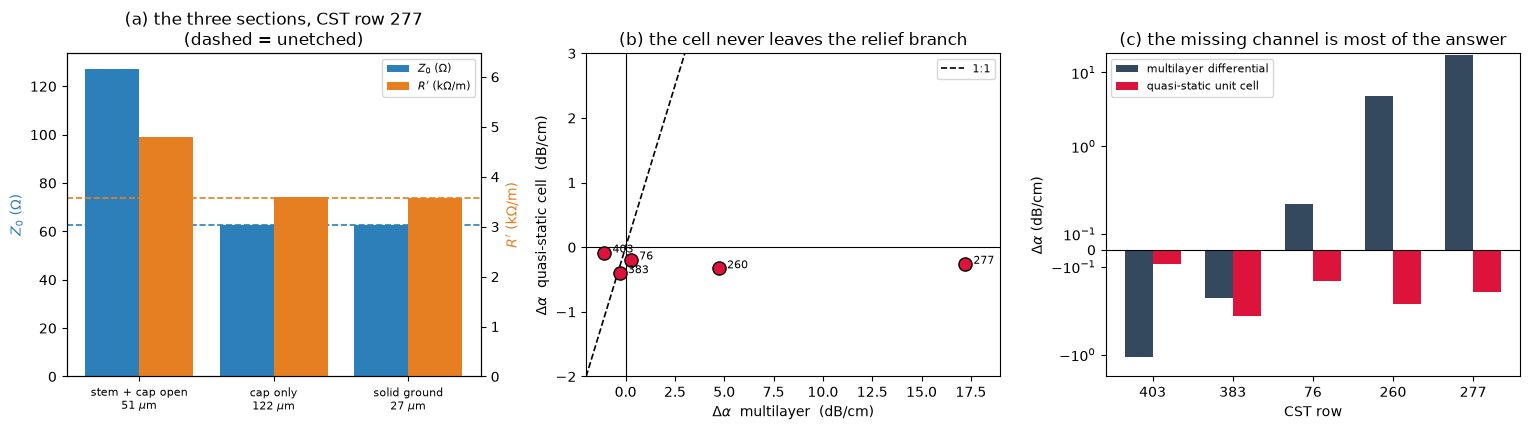

In [3]:
# %% [2] The periodic quasi-static unit cell -- what a mirror/periodic BC cell gives
#
# The proposal was: mesh ONE period with periodic (mirror) boundaries, solve it,
# and read the perturbation off directly -- no ports, so nothing to de-embed and
# no subtraction of a port artifact.  Cell [1] showed beta_0 p = 0.54 rad, so the
# period homogenises and that cell reduces to a quasi-static problem:
#
#     C' = (1/p) sum_i l_i C_i     charges add in parallel along z
#     L' = (1/p) sum_i l_i L_i     fluxes add in series along z
#     R' = (1/p) sum_i l_i R_i     dissipations add in series along z
#
# Each C_i, L_i, R_i is the ordinary 2D extraction already validated against
# COMSOL: C from the anisotropic Laplace solve, L = 1/(c^2 C_air) from the
# air-filled one, and R' = Rs * contour integral of |E_air.n|^2 / (C_air/eps0)^2,
# which is Wheeler's incremental-inductance rule written as a contour integral.
@BilinearForm
def _lap(u, v, w):
    return w.ex * grad(u)[0] * grad(v)[0] + w.ey * grad(u)[1] * grad(v)[1]


@Functional
def _dvdn2(w):
    return (w.gu.grad[0] * w.nx + w.gu.grad[1] * w.ny) ** 2


def extract2d(g, elem=ElementTriP1):
    mesh, mat = g["mesh"], g["mat"]
    is_metal, is_sig = g["is_metal"], g["is_sig"]
    basis = Basis(mesh, elem())
    bp0 = basis.with_element(ElementTriP0())
    ex = np.array([EPS[m][0] for m in mat]); ey = np.array([EPS[m][1] for m in mat])
    one = np.ones(mesh.nelements)
    dofs_sig = np.unique(basis.element_dofs[:, np.where(is_sig)[0]])
    dofs_D = np.unique(basis.element_dofs[:, np.where(is_metal)[0]])

    def run(a, b):
        K = asm(_lap, basis, ex=bp0.interpolate(a), ey=bp0.interpolate(b))
        uD = np.zeros(basis.N); uD[dofs_sig] = 1.0
        Kc, fc, uc, I = condense(K, np.zeros(basis.N), x=uD, D=dofs_D)
        u = uc.copy(); u[I] = solve(Kc, fc)
        return u, EPS0 * float((K @ u)[dofs_sig].sum())

    _, C_eps = run(ex, ey)
    V_air, C_air = run(one, one)

    f2t = mesh.f2t
    on = (f2t[1] >= 0) & (is_metal[f2t[0]] ^ is_metal[f2t[1]])
    tot = 0.0
    for side in (0, 1):
        oth = 1 - side
        fac = np.where(on & is_metal[f2t[oth]] & ~is_metal[f2t[side]])[0]
        if fac.size == 0:
            continue
        p = mesh.p[:, mesh.facets[:, fac]]
        tan = p[:, 1, :] - p[:, 0, :]
        nrm = np.vstack([tan[1], -tan[0]]); nrm /= np.linalg.norm(nrm, axis=0)
        mid = p.mean(axis=1)
        cen = mesh.p[:, mesh.t[:, f2t[oth][fac]]].mean(axis=1)
        nrm *= np.sign(((mid - cen) * nrm).sum(axis=0))
        fb = InteriorFacetBasis(mesh, elem(), facets=fac, side=side)
        tot += _dvdn2.assemble(fb, gu=fb.interpolate(V_air),
                               nx=nrm[0][:, None], ny=nrm[1][:, None])
    S = C_air / EPS0
    return dict(C=C_eps, C_air=C_air, L=1.0 / (C0 ** 2 * C_air),
                Rp=RS_AU * 1e6 * tot / S ** 2,
                n_m=np.sqrt(C_eps / C_air), Z0=1.0 / (C0 * np.sqrt(C_eps * C_air)),
                ntri=mesh.nelements)


def foms(C, L, Rp):
    Z0 = np.sqrt(L / C)
    return dict(n_m=C0 * np.sqrt(L * C), Z0=Z0,
                alpha=DB_PER_NEPER * (Rp / (2.0 * Z0)) / 100.0)


def bloch(sections, p=PITCH):
    """Exact ABCD cascade of the uniform sections -- no homogenisation assumed.
    Comparing it with the averaged line measures how good the averaging is."""
    M = np.eye(2, dtype=complex)
    for ln, r in sections:
        Z, n, Rp = r["Z0"], r["n_m"], r["Rp"]
        g = Rp / (2 * Z) + 1j * 2 * np.pi * F0 * n / C0
        gl = g * ln * 1e-6
        M = M @ np.array([[np.cosh(gl), Z * np.sinh(gl)],
                          [np.sinh(gl) / Z, np.cosh(gl)]])
    gB = np.arccosh((M[0, 0] + M[1, 1]) / 2.0) / (p * 1e-6)
    return dict(alpha=gB.real * DB_PER_NEPER / 100.0,
                n_m=gB.imag * C0 / (2 * np.pi * F0),
                Z0=float(np.real(np.sqrt(M[0, 1] / M[1, 0]))))


MESH = dict(mf=2.5, corner_res=0.12, skin_res=0.25)


def unit_cell(g, verbose=False):
    """Etched unit cell + its unetched reference, meshed with identical settings
    so every mesh-driven bias cancels in the difference."""
    secs = tee_sections(g["WS"], g["GAP"], g["W1"], g["W2"], g["L1"], g["L2"])
    wx = [-g["WS"] / 2, g["WS"] / 2]
    for _, sp, _ in secs:
        for a, b in sp:
            wx += [a, b, -a, -b]
    mp = wall_pitch(wx, 10.0)
    acc, per = dict(C=0.0, L=0.0, Rp=0.0), []
    for ln, sp, nm in secs:
        r = extract2d(build2d(g["WS"], g["GAP"], g["MTX"], g["cap_w"], g["wg_h"],
                              sp, min_pitch=mp, **MESH))
        per.append((ln, sp, nm, r))
        for k in acc:
            acc[k] += ln * r[k]
    eff = {k: v / PITCH for k, v in acc.items()}
    une = extract2d(build2d(g["WS"], g["GAP"], g["MTX"], g["cap_w"], g["wg_h"],
                            None, min_pitch=mp, **MESH))
    fe, fu = foms(eff["C"], eff["L"], eff["Rp"]), foms(une["C"], une["L"], une["Rp"])
    bl = bloch([(ln, r) for ln, _, _, r in per])
    return dict(sections=per, eff=eff, une=une, etched=fe, unetched=fu, bloch=bl,
                d_qs=fe["alpha"] - fu["alpha"], d_bloch=bl["alpha"] - fu["alpha"])


t0 = time.time()
CELLS = {}
for i in DEMO:
    CELLS[i] = unit_cell(geom_of(i))
t_cells = time.time() - t0

print("=" * 100)
print("PERIODIC QUASI-STATIC UNIT CELL  vs  THE MULTILAYER DIFFERENTIAL")
print("-" * 100)
print(f"{'row':>4} {'CST#':>5} | {'n_m':>7} {'Z0':>7} {'alpha':>7} | {'n_m':>7} {'Z0':>7} "
      f"{'alpha':>7} | {'d_cell':>8} {'d_Bloch':>8} {'d_ML':>9}")
print(f"{'':>4} {'':>5} | {'--- unetched cell ---':^23} | {'--- etched cell ---':^23} |")
for i in DEMO:
    c, g = CELLS[i], geom_of(i)
    print(f"{i:>4} {g['cst']:>5} | {c['unetched']['n_m']:>7.4f} {c['unetched']['Z0']:>7.2f} "
          f"{c['unetched']['alpha']:>7.3f} | {c['etched']['n_m']:>7.4f} "
          f"{c['etched']['Z0']:>7.2f} {c['etched']['alpha']:>7.3f} | "
          f"{c['d_qs']:>+8.3f} {c['d_bloch']:>+8.3f} {g['d']:>+9.3f}")
print("-" * 100)
print("unetched cell vs the COMSOL 2D baseline (the anchor both halves share):")
for i in DEMO:
    c, g = CELLS[i], geom_of(i)
    print(f"   row {i:>3}:  n_m {c['unetched']['n_m']:.4f} vs {g['n_m']:.4f} "
          f"({100*(c['unetched']['n_m']/g['n_m']-1):+.2f} %)   "
          f"Z0 {c['unetched']['Z0']:.2f} vs {g['Z0']:.2f} "
          f"({100*(c['unetched']['Z0']/g['Z0']-1):+.2f} %)   "
          f"alpha {c['unetched']['alpha']:.3f} vs {g['a_C']:.3f} "
          f"({100*(c['unetched']['alpha']/g['a_C']-1):+.2f} %)")
print(f"   (this cell runs a deliberately coarse mesh, {MESH}; the corner boxes of the")
print( "    2D notebook close the remaining alpha deficit -- it cancels in every delta)")
print("-" * 100)
print(f"homogenisation check: averaged line vs exact ABCD cascade of the same sections")
for i in DEMO:
    c = CELLS[i]
    print(f"   row {i:>3}:  alpha {c['etched']['alpha']:.4f} vs {c['bloch']['alpha']:.4f} "
          f"({100*(c['etched']['alpha']/c['bloch']['alpha']-1):+.2f} %)   "
          f"n_m {c['etched']['n_m']:.4f} vs {c['bloch']['n_m']:.4f}")
print("   -> averaging the period is worth a couple of percent; it is NOT the problem")
print("-" * 100)
# additivity / orthogonality, by construction
z = geom_of(DEMO[0]).copy(); z.update(W1=0.0, W2=0.0, L1=0.0, L2=0.0)
zc = unit_cell(z)
print(f"orthogonality: run the SAME cell with the tee removed -> "
      f"d_cell = {zc['d_qs']:+.3e} dB/cm")
print( "   the cell collapses onto its own unetched reference identically, so the")
print( "   perturbation it produces cannot double count anything in the 2D baseline")
print(f"\n{len(DEMO)} unit cells in {t_cells:.1f} s")
print("=" * 100)
print("VERDICT: the quasi-static cell tracks the RELIEF branch and produces no")
print("penalty branch at all.  It is additive and orthogonal, but it is not 1:1.")
print("=" * 100)

# ---- figure ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15.4, 4.4))

ax = axes[0]
c = CELLS[DEMO[-1]]
lab = [f"{nm}\n{ln:.0f} $\\mu$m" for ln, _, nm, _ in c["sections"]]
zz = [r["Z0"] for _, _, _, r in c["sections"]]
rr = [r["Rp"] / 1e3 for _, _, _, r in c["sections"]]
xx = np.arange(len(lab))
ax.bar(xx - 0.2, zz, 0.4, label=r"$Z_0$ ($\Omega$)", color="#2c7fb8")
ax.axhline(c["une"]["Z0"], color="#2c7fb8", ls="--", lw=1.2)
ax.set_ylabel(r"$Z_0$ ($\Omega$)", color="#2c7fb8")
ax2 = ax.twinx()
ax2.bar(xx + 0.2, rr, 0.4, label=r"$R'$ (k$\Omega$/m)", color="#e67e22")
ax2.axhline(c["une"]["Rp"] / 1e3, color="#e67e22", ls="--", lw=1.2)
ax2.set_ylabel(r"$R'$ (k$\Omega$/m)", color="#e67e22")
ax2.set_ylim(0, max(rr) * 1.35)
ax.set_xticks(xx); ax.set_xticklabels(lab, fontsize=8)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")
ax.set_title(f"(a) the three sections, CST row "
             f"{geom_of(DEMO[-1])['cst']}\n(dashed = unetched)")

ax = axes[1]
dq = [CELLS[i]["d_qs"] for i in DEMO]
dm = [geom_of(i)["d"] for i in DEMO]
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
lim = [-2, 19]
ax.plot(lim, lim, "k--", lw=1.2, label="1:1")
ax.scatter(dm, dq, s=90, c="crimson", edgecolors="k", zorder=3)
for i, x, y in zip(DEMO, dm, dq):
    ax.annotate(f"  {geom_of(i)['cst']}", (x, y), fontsize=8)
ax.set_xlim(lim); ax.set_ylim(-2, 3)
ax.set_xlabel(r"$\Delta\alpha$  multilayer  (dB/cm)")
ax.set_ylabel(r"$\Delta\alpha$  quasi-static cell  (dB/cm)")
ax.set_title("(b) the cell never leaves the relief branch"); ax.legend(fontsize=8)

ax = axes[2]
w = 0.35; xx = np.arange(len(DEMO))
ax.bar(xx - w / 2, dm, w, label="multilayer differential", color="#34495e")
ax.bar(xx + w / 2, dq, w, label="quasi-static unit cell", color="crimson")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(xx); ax.set_xticklabels([str(geom_of(i)["cst"]) for i in DEMO])
ax.set_xlabel("CST row"); ax.set_ylabel(r"$\Delta\alpha$ (dB/cm)")
ax.set_yscale("symlog", linthresh=0.5)
ax.legend(fontsize=8); ax.set_title("(c) the missing channel is most of the answer")
plt.tight_layout(); plt.show()


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


...

Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


OHMIC CEILING:  CURRENT DETOUR IN THE SLOTTED GROUND
------------------------------------------------------------------------------------------------
  solid ground               1.429 squares / half period   -> R' = 514.8 ohm/m  (= Rs/(2 W_G) = 514.8, checks out)
  sweep of 498 footprints in 17.9 s
  extra squares dN : median 1.75  p90 6.92  max 16.98
  detour alpha     : median 0.627  p90 2.438  max 6.572 dB/cm
------------------------------------------------------------------------------------------------
  on the 286 rows with delta_ML > 0.2 dB/cm:
     delta_ML / detour : median 1.05x   p75 1.87x   p90 2.76x   max 8.3x
     the detour covers the whole delta on 130 rows, more than half of it on 224
     squares NEEDED  : median 3.2  p90 16  max 71
     squares OFFERED : median 3.2  p90 8.2  max 17.0
     rows demanding more squares than a half period laid along the whole
     surviving rim can supply (a hard topological cap): 73 of 286
----------------------------------------------

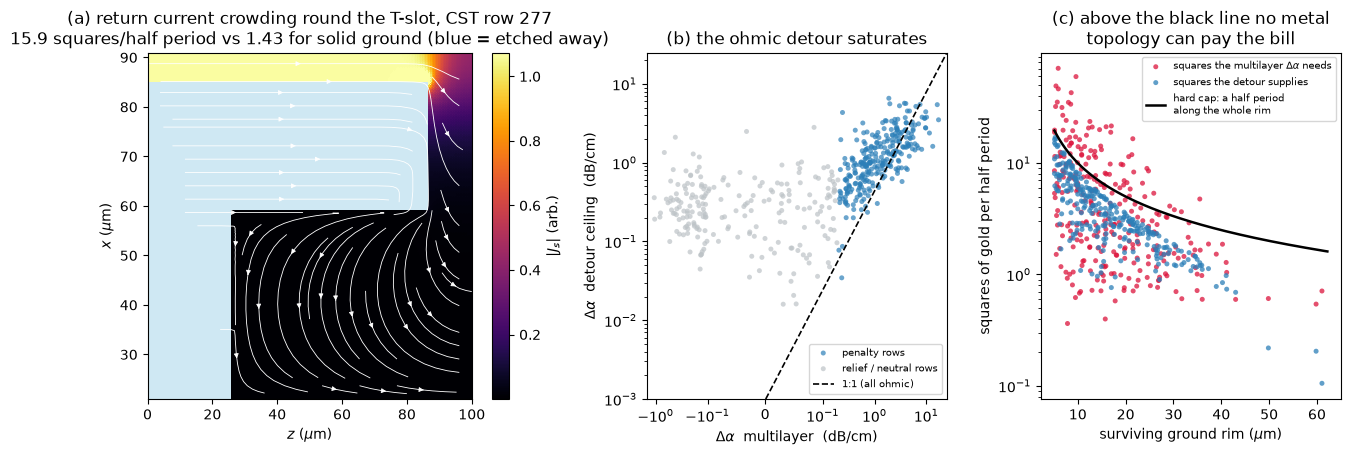

In [4]:
# %% [3] The ohmic ceiling -- how much extra loss the current detour can possibly buy
#
# Cell [2] changed the cross-sections but kept every section's current in its own
# 2D modal distribution.  The one ohmic channel that leaves out is the LONGITUDINAL
# detour: the T-slot interrupts the inner part of the ground, so the return current
# has to cross to the surviving outer rim and back once per period.
#
# Model it as sheet conduction on the ground footprint, with the period built in:
#   phi = -E0 z + psi,   J = (1/Rs)(E0 zhat - grad psi),   div J = 0
# psi is odd about z = 0 (slot centre) and about z = p/2 (mid-metal), so psi = 0 on
# both planes; the slot rim and the two ground edges are insulating.
#
# Two deliberate biases, both FAVOURABLE to the "it is all ohmic" hypothesis:
#   * the sheet carries Rs per square, i.e. current on ONE face.  Real metal is
#     MTX = 1..15 um thick against a 304 nm skin depth, so both faces and the
#     sidewalls conduct and the true detour is nearer Rs/2 -- half of what is
#     charged here.
#   * the squares are converted with the UNETCHED impedance; etching raises Z0
#     (cell [2]: +9 to +22 %), which raises the loss a given R' buys.
@BilinearForm
def _sheet(u, v, w):
    return dot(grad(u), grad(v))


@LinearForm
def _drive(v, w):
    return grad(v)[1]                                   # unit E0 along z


@Functional
def _diss(w):
    return w.gp.grad[0] ** 2 + (1.0 - w.gp.grad[1]) ** 2


def _grid(xs, zs):
    X, Z = np.meshgrid(xs, zs, indexing="ij")
    nz = len(zs)
    tri = []
    for i in range(len(xs) - 1):
        for j in range(nz - 1):
            a, b, c, d = i * nz + j, (i + 1) * nz + j, (i + 1) * nz + j + 1, i * nz + j + 1
            tri += [[a, b, c], [a, c, d]]
    return np.vstack([X.ravel(), Z.ravel()]), np.array(tri).T


def _axis(lo, hi, breaks, h):
    b = np.unique(np.clip(np.r_[lo, breaks, hi], lo, hi))
    return np.unique(np.concatenate(
        [np.linspace(b[k], b[k + 1], max(2, int(np.ceil((b[k + 1] - b[k]) / h)) + 1))
         for k in range(len(b) - 1)]))


def detour(WS, GAP, W1, W2, L1, L2, p=PITCH, wg=WG, h=1.6, want_field=False):
    """Squares of gold the return current crosses per HALF period, one ground."""
    x_gi = WS / 2.0 + GAP; x_go = x_gi + wg
    a, b, c = x_gi, min(x_gi + W1, x_go), min(x_gi + W1 + W2, x_go)
    xs = _axis(x_gi, x_go, [a, b, c], h)
    zs = _axis(0.0, p / 2, [min(L1, p) / 2, min(L2, p) / 2], h)
    pts, t = _grid(xs, zs)
    xc, zc = pts[0, t].mean(axis=0), pts[1, t].mean(axis=0)
    keep = ~(((xc > a) & (xc < b) & (zc < L1 / 2)) |
             ((xc > b) & (xc < c) & (zc < L2 / 2)))
    t = t[:, keep]
    # nodes stranded inside the removed slot carry no element, so they would put
    # empty rows into the stiffness matrix; drop them and renumber
    used = np.unique(t)
    remap = np.full(pts.shape[1], -1, dtype=int); remap[used] = np.arange(used.size)
    m = MeshTri(pts[:, used], remap[t])
    basis = Basis(m, ElementTriP1())
    D = basis.get_dofs(lambda q: (np.abs(q[1]) < 1e-9) | (np.abs(q[1] - p / 2) < 1e-9))
    psi = solve(*condense(asm(_sheet, basis), asm(_drive, basis), D=D))
    Pd = _diss.assemble(basis, gp=basis.interpolate(psi))     # = P * Rs, in um^2
    V = p / 2.0
    N = V / (Pd / V) if Pd > 0 else np.nan                    # squares per half period
    return (float(N), m, psi, basis) if want_field else float(N)


N_FLAT = (PITCH / 2.0) / WG                                   # solid ground, analytic

# ---- the demo row ----------------------------------------------------------
gd = geom_of(DEMO[-1])
Nd, md, psid, bd = detour(gd["WS"], gd["GAP"], gd["W1"], gd["W2"], gd["L1"], gd["L2"],
                          h=0.5, want_field=True)

# ---- the whole sweep -------------------------------------------------------
t0 = time.time()
Nall = np.array([detour(r.WS, r.GAP, r.W1, r.W2, r.L1, r.L2)
                 for _, r in REF.iterrows()])
t_sweep = time.time() - t0
dN = Nall - N_FLAT                                            # extra squares, half period
dRp = dN * RS_AU / (PITCH * 1e-6)                             # ohm/m
da_detour = DB_PER_NEPER * dRp / (2.0 * REF.Z0_COMSOL.values) / 100.0
# squares the multilayer delta would need if it were purely ohmic
need = (REF.delta_ML.values / DB_PER_NEPER * 100.0 * 2.0 * REF.Z0_COMSOL.values
        * (PITCH * 1e-6) / RS_AU)
rim = (WG - REF.W1 - REF.W2).values                           # surviving ground rim
cap = PITCH / 2.0 / np.maximum(rim, 1e-9)                     # hard topological cap
pos = REF.delta_ML.values > 0.2

print("=" * 96)
print("OHMIC CEILING:  CURRENT DETOUR IN THE SLOTTED GROUND")
print("-" * 96)
print(f"  solid ground               {N_FLAT:.3f} squares / half period   "
      f"-> R' = {N_FLAT*RS_AU/(PITCH*1e-6):.1f} ohm/m"
      f"  (= Rs/(2 W_G) = {RS_AU/(2*WG*1e-6):.1f}, checks out)")
print(f"  sweep of {len(REF)} footprints in {t_sweep:.1f} s")
print(f"  extra squares dN : median {np.median(dN):.2f}  p90 {np.quantile(dN,.9):.2f}"
      f"  max {dN.max():.2f}")
print(f"  detour alpha     : median {np.median(da_detour):.3f}  "
      f"p90 {np.quantile(da_detour,.9):.3f}  max {da_detour.max():.3f} dB/cm")
print("-" * 96)
print(f"  on the {pos.sum()} rows with delta_ML > 0.2 dB/cm:")
rat = REF.delta_ML.values[pos] / da_detour[pos]
print(f"     delta_ML / detour : median {np.median(rat):.2f}x   "
      f"p75 {np.quantile(rat,.75):.2f}x   p90 {np.quantile(rat,.9):.2f}x   max {rat.max():.1f}x")
print(f"     the detour covers the whole delta on {(rat<1).sum()} rows, "
      f"more than half of it on {(rat<2).sum()}")
print(f"     squares NEEDED  : median {np.median(need[pos]):.1f}  "
      f"p90 {np.quantile(need[pos],.9):.0f}  max {need[pos].max():.0f}")
print(f"     squares OFFERED : median {np.median(dN[pos]):.1f}  "
      f"p90 {np.quantile(dN[pos],.9):.1f}  max {dN[pos].max():.1f}")
imposs = pos & (need > cap)
N_POS, N_IMPOSS = int(pos.sum()), int(imposs.sum())
print(f"     rows demanding more squares than a half period laid along the whole")
print(f"     surviving rim can supply (a hard topological cap): "
      f"{imposs.sum()} of {pos.sum()}")
print("-" * 96)
print("  So the detour is a real channel and it carries the median penalty row --")
print("  but it saturates.  The upper half of the distribution, and every one of")
print(f"  the {imposs.sum()} rows above the topological cap, cannot be bought with gold.")
print("=" * 96)

# ---- figure ----------------------------------------------------------------
from scipy.interpolate import griddata                                  # noqa: E402

fig = plt.figure(figsize=(15.4, 4.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1, 1], wspace=0.28)

ax = fig.add_subplot(gs[0, 0])
cx = md.p[0, md.t].mean(axis=0); cz = md.p[1, md.t].mean(axis=0)
gu = bd.interpolate(psid).grad
Jx = -gu[0].mean(axis=1); Jz = 1.0 - gu[1].mean(axis=1)
Jm = np.hypot(Jx, Jz)
ax.set_facecolor("#cfe8f3")                       # the etched-away T-slot
tp = ax.tripcolor(md.p[1], md.p[0], md.t.T, facecolors=Jm, cmap="inferno",
                  shading="flat", vmax=np.quantile(Jm, 0.995))
zi = np.linspace(0, PITCH / 2, 90)
xi = np.linspace(gd["WS"] / 2 + gd["GAP"], gd["WS"] / 2 + gd["GAP"] + WG, 70)
ZI, XI = np.meshgrid(zi, xi)
U = griddata((cz, cx), Jz, (ZI, XI)); V = griddata((cz, cx), Jx, (ZI, XI))
ax.streamplot(zi, xi, U, V, color="w", density=0.9, linewidth=0.6, arrowsize=0.7)
ax.set_xlabel(r"$z$ ($\mu$m)"); ax.set_ylabel(r"$x$ ($\mu$m)")
ax.set_title(f"(a) return current crowding round the T-slot, CST row {gd['cst']}\n"
             f"{Nd:.1f} squares/half period vs {N_FLAT:.2f} for solid ground "
             f"(blue = etched away)")
plt.colorbar(tp, ax=ax, label=r"$|J_s|$ (arb.)")

ax = fig.add_subplot(gs[0, 1])
ax.scatter(REF.delta_ML[pos], da_detour[pos], s=13, c="#2c7fb8",
           alpha=0.7, edgecolors="none", label="penalty rows")
ax.scatter(REF.delta_ML[~pos], da_detour[~pos], s=13, c="#bdc3c7",
           alpha=0.7, edgecolors="none", label="relief / neutral rows")
lim = [1e-3, 25]
ax.plot(lim, lim, "k--", lw=1.2, label="1:1 (all ohmic)")
ax.set_xscale("symlog", linthresh=0.1); ax.set_yscale("log")
ax.set_xlim(-1.5, 25); ax.set_ylim(1e-3, 25)
ax.set_xlabel(r"$\Delta\alpha$  multilayer  (dB/cm)")
ax.set_ylabel(r"$\Delta\alpha$  detour ceiling  (dB/cm)")
ax.set_title("(b) the ohmic detour saturates"); ax.legend(fontsize=7.5, loc="lower right")

ax = fig.add_subplot(gs[0, 2])
ax.scatter(rim[pos], need[pos], s=13, c="crimson", alpha=0.75, edgecolors="none",
           label=r"squares the multilayer $\Delta\alpha$ needs")
ax.scatter(rim[pos], dN[pos], s=13, c="#2c7fb8", alpha=0.75, edgecolors="none",
           label="squares the detour supplies")
rr = np.linspace(rim.min(), rim.max(), 200)
ax.plot(rr, PITCH / 2 / rr, "k-", lw=1.8,
        label="hard cap: a half period\nalong the whole rim")
ax.set_yscale("log"); ax.set_xlabel(r"surviving ground rim ($\mu$m)")
ax.set_ylabel("squares of gold per half period")
ax.set_title("(c) above the black line no metal\ntopology can pay the bill")
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


(A) THE UNETCHED BASELINE:  multilayer differential  vs  COMSOL 2D FEM
------------------------------------------------------------------------------------------------
  COMSOL - multilayer : mean +0.1507 dB/cm, min +0.0401, max +0.5250
  as a fraction       : mean +7.04 %, sd 1.71 %   -- and POSITIVE on all 498 rows
     corr(gap %, GAP       ) = -0.411
     corr(gap %, MTX       ) = +0.297
     corr(gap %, WS        ) = +0.011
     corr(gap %, ETCH_DEPTH) = +0.154
------------------------------------------------------------------------------------------------
  The multilayer solver sits BELOW COMSOL on every single geometry, and the
  shortfall tracks GAP and MTX -- the two parameters that set how sharp the
  electrode corner is.  That is the signature of an under-resolved edge
  singularity on a first-order surface mesh, not of an extra loss channel:
  a leakage channel would push the multilayer number UP, not down.
  => on the UNIFORM line, leakage is below the 7 % meshing residua

     aperture_area      +0.069
     slot_reach_W1      +0.220
     ground_severed     +0.009
     cap_duty_L2        +0.333
     stem_duty_L1       -0.146
     metal_thickness    -0.441
------------------------------------------------------------------------------------------------
  The two strongest are the cap duty cycle L2/p (+) and the metal thickness (-).
  Both are aperture signatures.  L2 sets how long the opening is along z; MTX
  sets how DEEP it is, and a slot cut through thicker gold is a longer stretch
  of below-cutoff channel between the gap field and the substrate, so it leaks
  less.  An ohmic mechanism would not give that: thicker metal lowers R', and
  that dependence has already been taken out with the detour term.  How much
  ground is severed ranks at +0.01 here precisely because the detour term
  absorbed it.
  The attribution still rests on elimination, not on this ranking: cell [1]
  showed the TE0 channel is the only one open, cell [2] closed the reactive
  ro

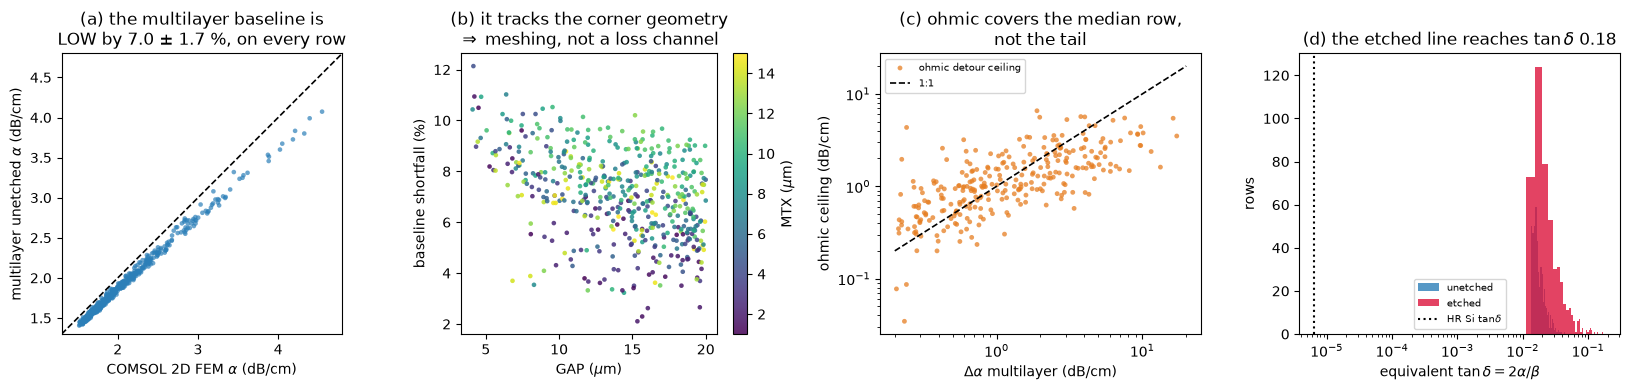

In [5]:
# %% [4] Confrontation with the 500-geometry multilayer sweep
#
# Three things get tested here, in order:
#   (A) is the multilayer solver's UNETCHED baseline carrying a loss channel the
#       2D FEM does not have?  If it were, it would sit ABOVE COMSOL.
#   (B) how much of the perturbation does the full ohmic budget (cell [2]'s
#       cross-section change + cell [3]'s detour ceiling) actually buy?
#   (C) what does the remainder look like?
DBn = DB_PER_NEPER
beta = 2.0 * np.pi * F0 * REF.n_m_COMSOL.values / C0                  # rad/m
tand_u = 2.0 * (REF.alpha_ML_unetched.values / DBn * 100.0) / beta
tand_e = 2.0 * (REF.alpha_ML_etched.values / DBn * 100.0) / beta
gapfrac = 100.0 * REF.baseline_gap.values / REF.alpha_COMSOL.values

print("=" * 96)
print("(A) THE UNETCHED BASELINE:  multilayer differential  vs  COMSOL 2D FEM")
print("-" * 96)
print(f"  COMSOL - multilayer : mean {REF.baseline_gap.mean():+.4f} dB/cm, "
      f"min {REF.baseline_gap.min():+.4f}, max {REF.baseline_gap.max():+.4f}")
print(f"  as a fraction       : mean {gapfrac.mean():+.2f} %, sd {gapfrac.std():.2f} %"
      f"   -- and POSITIVE on all {len(REF)} rows")
for c in ("GAP", "MTX", "WS", "ETCH_DEPTH"):
    print(f"     corr(gap %, {c:<10}) = {np.corrcoef(gapfrac, REF[c])[0,1]:+.3f}")
print("-" * 96)
print("  The multilayer solver sits BELOW COMSOL on every single geometry, and the")
print("  shortfall tracks GAP and MTX -- the two parameters that set how sharp the")
print("  electrode corner is.  That is the signature of an under-resolved edge")
print("  singularity on a first-order surface mesh, not of an extra loss channel:")
print("  a leakage channel would push the multilayer number UP, not down.")
print("  => on the UNIFORM line, leakage is below the 7 % meshing residual, exactly")
print("     as the lambda0/170 aperture of cell [1] predicts.  The 2D FEM baseline")
print("     is free to be a purely ohmic + dielectric calculation.")
print("=" * 96)

ohm_qs = np.array([CELLS[i]["d_qs"] for i in DEMO])
ohm_det = da_detour[DEMO]
ohm_tot = ohm_qs + ohm_det
d_ml = REF.delta_ML.values[DEMO]
print("(B) THE FULL OHMIC BUDGET ON THE FIVE DEMO ROWS")
print("-" * 96)
print(f"{'row':>4} {'CST#':>5} {'rim':>6} | {'cross-sec':>10} {'detour':>9} {'ohmic tot':>10}"
      f" | {'delta_ML':>9} | {'covered':>8}")
for k, i in enumerate(DEMO):
    g = geom_of(i)
    print(f"{i:>4} {g['cst']:>5} {WG-g['W1']-g['W2']:>6.1f} | {ohm_qs[k]:>+10.3f} "
          f"{ohm_det[k]:>+9.3f} {ohm_tot[k]:>+10.3f} | {d_ml[k]:>+9.3f} | "
          f"{'n/a' if d_ml[k] <= 0 else f'{100*ohm_tot[k]/d_ml[k]:>7.0f} %':>8}")
print("-" * 96)
print("  Row 383 lands almost exactly (-0.281 against -0.293).  Row 403 does not: the")
print("  cross-section term has the right sign but is far too small, and the detour")
print("  ceiling -- deliberately generous -- then over-charges it into the wrong sign")
print("  altogether.  Read that as what it is: the ceiling is an upper bound, not an")
print("  estimate, and on a row with a 42 um rim the true detour is a fraction of it.")
print("  The penalty rows are the real point.  Row 260, whose ground is nearly severed")
print("  (8.7 um rim), is 89 % ohmic -- the detour genuinely is the mechanism there.")
print("  Row 277 is not: 3.2 of 17.2 dB/cm, and that is with every thumb on the scale.")
print("=" * 96)

res = REF.delta_ML.values - (da_detour)           # detour-only residual, all 498
pos = REF.delta_ML.values > 0.2
print("(C) WHAT IS LEFT OVER")
print("-" * 96)
print(f"  equivalent loss tangent 2 alpha / beta of the line at 60 GHz:")
print(f"     unetched : median {np.median(tand_u):.4f}   max {tand_u.max():.4f}")
print(f"     etched   : median {np.median(tand_e):.4f}   p90 {np.quantile(tand_e,.9):.4f}"
      f"   max {tand_e.max():.4f}")
print(f"  for scale: HR silicon at 2.5e-4 S/m has tan(delta) = "
      f"{2.5e-4/(2*np.pi*F0*EPS0*11.7):.2e}, LN and SiO2 are lower still,")
print(f"  and the gold itself only reaches tan(delta) ~ {np.median(tand_u):.3f} on the")
print(f"  unetched line.  A Q of {beta.mean()/(2*REF.alpha_ML_etched.max()/DBn*100):.1f}"
      f" is not something this stack can dissipate.")
print("-" * 96)
print("  rank correlation of the residual (delta_ML - detour) with geometry,")
print(f"  over the {pos.sum()} penalty rows -- a consistency check, NOT a fit:")
ap = pd.DataFrame(dict(
    residual=res[pos],
    aperture_area=((REF.L1 * REF.W1 + REF.L2 * REF.W2) / (PITCH * WG)).values[pos],
    slot_reach_W1=REF.W1.values[pos],
    ground_severed=((REF.W1 + REF.W2) / WG).values[pos],
    cap_duty_L2=(REF.L2 / PITCH).values[pos],
    stem_duty_L1=(REF.L1 / PITCH).values[pos],
    metal_thickness=REF.MTX.values[pos]))
for c in ap.columns[1:]:
    print(f"     {c:<18} {ap.residual.corr(ap[c], method='spearman'):+.3f}")
print("-" * 96)
print("  The two strongest are the cap duty cycle L2/p (+) and the metal thickness (-).")
print("  Both are aperture signatures.  L2 sets how long the opening is along z; MTX")
print("  sets how DEEP it is, and a slot cut through thicker gold is a longer stretch")
print("  of below-cutoff channel between the gap field and the substrate, so it leaks")
print("  less.  An ohmic mechanism would not give that: thicker metal lowers R', and")
print("  that dependence has already been taken out with the detour term.  How much")
print("  ground is severed ranks at +0.01 here precisely because the detour term")
print("  absorbed it.")
print("  The attribution still rests on elimination, not on this ranking: cell [1]")
print("  showed the TE0 channel is the only one open, cell [2] closed the reactive")
print("  route and cell [3] closed the ohmic one.")
print("=" * 96)

# ---- figure ----------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16.6, 4.0))

ax = axes[0]
ax.scatter(REF.alpha_COMSOL, REF.alpha_ML_unetched, s=11, c="#2c7fb8",
           alpha=0.7, edgecolors="none")
lim = [1.3, 4.8]
ax.plot(lim, lim, "k--", lw=1.2)
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_xlabel(r"COMSOL 2D FEM $\alpha$ (dB/cm)")
ax.set_ylabel(r"multilayer unetched $\alpha$ (dB/cm)")
ax.set_title(f"(a) the multilayer baseline is\nLOW by {gapfrac.mean():.1f} "
             f"$\\pm$ {gapfrac.std():.1f} %, on every row")

ax = axes[1]
sc = ax.scatter(REF.GAP, gapfrac, s=11, c=REF.MTX, cmap="viridis", alpha=0.85,
                edgecolors="none")
plt.colorbar(sc, ax=ax, label=r"MTX ($\mu$m)")
ax.set_xlabel(r"GAP ($\mu$m)"); ax.set_ylabel("baseline shortfall (%)")
ax.set_title("(b) it tracks the corner geometry\n$\\Rightarrow$ meshing, not a loss channel")

ax = axes[2]
ax.scatter(REF.delta_ML[pos], da_detour[pos] + 0.0, s=12, c="#e67e22",
           alpha=0.75, edgecolors="none", label="ohmic detour ceiling")
ax.plot([0.2, 20], [0.2, 20], "k--", lw=1.2, label="1:1")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\Delta\alpha$ multilayer (dB/cm)")
ax.set_ylabel(r"ohmic ceiling (dB/cm)")
ax.set_title("(c) ohmic covers the median row,\nnot the tail")
ax.legend(fontsize=7.5, loc="upper left")

ax = axes[3]
ax.hist(tand_u, bins=40, alpha=0.8, color="#2c7fb8", label="unetched")
ax.hist(tand_e, bins=40, alpha=0.8, color="crimson", label="etched")
ax.axvline(2.5e-4 / (2 * np.pi * F0 * EPS0 * 11.7), color="k", ls=":",
           label=r"HR Si tan$\delta$")
ax.set_xscale("log"); ax.set_xlabel(r"equivalent $\tan\delta = 2\alpha/\beta$")
ax.set_ylabel("rows"); ax.legend(fontsize=7.5)
ax.set_title(r"(d) the etched line reaches $\tan\delta$ 0.18")
plt.tight_layout(); plt.show()


WHY THE COMPOSITE WORKS

  alpha_total = alpha_2D_FEM  +  [ alpha_ML(etched) - alpha_ML(unetched) ]
                \___________/     \_______________________________________/
                 ohmic + dielectric        everything the tee ADDS

  The multilayer solver is a surface-integral (MoM) method whose Green's function
  is the one of the whole layered stack, laterally infinite and open.  That single
  choice puts THREE loss channels in it at once: the lossy-metal surface impedance
  (Rs = 72.07 mOhm/sq), the conduction loss of the Silicon (lossy) layer, and --
  because the layered Green's function carries the surface-wave poles and the
  branch cuts of the stack -- radiation and substrate leakage.  Nothing has to be
  switched on for the third one; SetOpenBC_XY True and Multilayer True are enough.

  The 2D FEM baseline has only the first two.  It solves for a BOUND eigenmode of
  a z-invariant cross-section inside a closed box; a leaky mode is a different
  mathematical object 

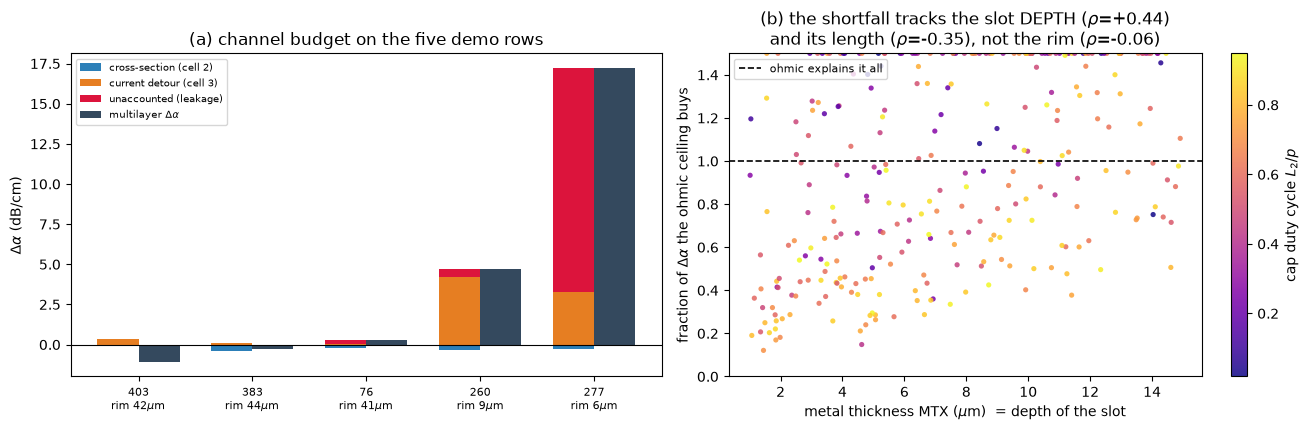

In [6]:
# %% [5] Verdict, and the four routes to a code perturbation
n_bar = float(REF.n_m_COMSOL.mean())
k_lat = k0 * np.sqrt(n_TE[0] ** 2 - n_bar ** 2)          # rad/um, TE0 leakage wave
lam_lat = 2 * np.pi / k_lat

print("=" * 96)
print("WHY THE COMPOSITE WORKS")
print("=" * 96)
print("""
  alpha_total = alpha_2D_FEM  +  [ alpha_ML(etched) - alpha_ML(unetched) ]
                \\___________/     \\_______________________________________/
                 ohmic + dielectric        everything the tee ADDS

  The multilayer solver is a surface-integral (MoM) method whose Green's function
  is the one of the whole layered stack, laterally infinite and open.  That single
  choice puts THREE loss channels in it at once: the lossy-metal surface impedance
  (Rs = 72.07 mOhm/sq), the conduction loss of the Silicon (lossy) layer, and --
  because the layered Green's function carries the surface-wave poles and the
  branch cuts of the stack -- radiation and substrate leakage.  Nothing has to be
  switched on for the third one; SetOpenBC_XY True and Multilayer True are enough.

  The 2D FEM baseline has only the first two.  It solves for a BOUND eigenmode of
  a z-invariant cross-section inside a closed box; a leaky mode is a different
  mathematical object (complex beta, fields growing away from the guide) and a
  bound-mode eigensolver cannot return one.  The scattering boundary absorbs what
  reaches it, but for a mode whose transverse fields die out over ~(S+2W) ~ 30 um
  inside 200 um of padding, nothing does.

  That mismatch does not matter for the baseline and the data proves it: over all
  498 rows the multilayer unetched number sits BELOW COMSOL, by {gf:.1f} +/- {gs:.1f} %,
  on every single geometry, and the shortfall tracks GAP and MTX.  An extra loss
  channel would push it UP.  What that residual actually is, is a first-order
  surface mesh under-resolving the r^(-1/3) edge singularity -- the same deficit
  the 2D notebook's corner boxes were built to close.

  So the two halves are orthogonal for a concrete reason, not by assumption:
    * the baseline term is the uniform line's ohmic loss, computed where it is
      computed best (corner-resolved IBC contour integral);
    * the differential term is identically zero when the tee is absent, so it
      cannot double count that;
    * and it carries the one channel the baseline structurally lacks -- plus, as
      a bonus, it cancels the multilayer solver's own -{gf:.0f} % ohmic bias, because
      that bias is present in both of its runs.
  That is why the composite matched the 3D time-domain N+1 - N extraction.
""".format(gf=gapfrac.mean(), gs=gapfrac.std()))

print("=" * 96)
print("WHAT THE PERTURBATION ACTUALLY IS")
print("=" * 96)
print(f"""
  cell [1]  at p = {PITCH:.0f} um every Floquet harmonic but m = 0 is evanescent (the
            m = -1 lobe needs p > {p_lobe:.0f} um), and beta_0 p = {k0*n_hi*PITCH:.2f} rad, so the
            period homogenises.  The mode itself, n_m = {n_lo:.2f}..{n_hi:.2f}, sits BELOW the
            TE0 surface wave of the 550 um silicon slab, n = {n_TE[0]:.4f}.  Exactly one
            radiative channel is open, and it is open for every geometry.
  cell [2]  the homogenised quasi-static cell -- a complete, Wheeler-exact account
            of the etched line's conductor loss -- gives delta in [{min(CELLS[i]['d_qs'] for i in DEMO):+.2f}, {max(CELLS[i]['d_qs'] for i in DEMO):+.2f}] dB/cm
            across rows whose true delta spans [{REF.delta_ML.min():+.2f}, {REF.delta_ML.max():+.2f}].  It has a relief branch of
            the right sign, and no penalty branch at all.
  cell [3]  the longitudinal current detour, charged generously, covers the median
            penalty row (1.05x) and then saturates: {N_IMPOSS} of {N_POS} penalty rows demand more
            squares of gold per period than the surviving ground rim physically has.
  cell [4]  the worst rows sit at tan(delta) = {tand_e.max():.3f}, a Q of about
            {beta.mean()/(2*REF.alpha_ML_etched.max()/DBn*100):.0f}.  No metal or dielectric in this stack dissipates like that.

  => the tee perturbation is a MIXTURE, and which half dominates is set by how
     much ground survives.  Relief, and penalty rows down to a nearly-severed
     ground, are ohmic and reactive -- a wider effective gap, a higher Z0, a
     longer return path.  The upper half of the penalty distribution is not
     reachable that way at all; it is aperture leakage into the silicon TE0
     surface wave, through the hole the tee cuts in the ground shield.
""")

print("=" * 96)
print("ROUTES TO A CODE PERTURBATION")
print("=" * 96)
print(f"""
  A.  PERIODIC QUASI-STATIC UNIT CELL          built, this notebook, ~20 s/geometry
      Mirror/periodic cell, no ports, nothing to de-embed -- and it IS additive
      and orthogonal: cell [2] showed it collapses onto its own unetched
      reference to machine zero when the tee is removed.  But it is NOT 1:1.  A
      static formulation has no radiation channel of any kind, so it is blind to
      the dominant term over half the design space.  Keep it as the ohmic half;
      do not ship it as the perturbation.

  A+. QUASI-STATIC CELL + RECIPROCITY LEAKAGE INTEGRAL      ~seconds, days to build
      The missing channel is one well-defined number: the power the slot aperture
      couples into a single, known mode.  Take the aperture field from A, take
      the TE0 profile from the 1D stack solve already in cell [1], and evaluate
      the layered-medium reciprocity integral for the coupled power; divide by
      the guided power and the period.  This is first order (Born), so it is
      honest only while the leakage is a perturbation -- at the top of the sweep
      {REF.delta_ML.max()*0.02:.2f} dB per period is ~{100*(1-10**(-REF.delta_ML.max()*0.02/10)):.0f} % of the power, where first order is
      already strained.  Cheapest credible route to covering most of the space.

  B.  3D FLOQUET FULL-WAVE UNIT CELL WITH PML              rigorous, but not fast
      Vector wave equation on one period, exp(-j beta p) phase boundaries, PML on
      the open sides; the complex Bloch eigenvalue gives ohmic AND leakage at
      once, with no ports and no subtraction.  The cost is the leakage wave
      itself: it leaves the guide with a lateral wavenumber k0 sqrt(n_TE0^2 -
      n_m^2), i.e. a lateral wavelength of {lam_lat:.0f} um.  The PML has to sit far
      enough out to absorb a {lam_lat/1000:.1f} mm wave while the mesh still resolves a
      0.1 um slot rim.  That is a multi-million-DOF nonlinear complex eigenproblem
      -- hours in Python, not the couple of minutes asked for.

  C.  LAYERED-MEDIUM MoM  (a 1:1 translation of the multilayer solver)  RECOMMENDED
      Same method CST uses: mixed-potential integral equation, RWG basis on the
      metal only, layered-medium (Sommerfeld) Green's function, lossy-metal
      surface impedance.  The reason this is fast and B is not: the 550 um
      substrate, the {lam_lat/1000:.1f} mm lateral reach and the open boundary all live in the
      Green's function and cost nothing -- unknowns exist only on the gold.
      Two further simplifications are specific to this stack:
        * every conductor is coplanar (all metal sits on the LN surface), so the
          Green's function reduces to a ONE-DIMENSIONAL table in rho, built once
          by numerical Sommerfeld integration and interpolated thereafter;
        * one period is {PITCH:.0f} x ~200 um of metal; at CST's own 5 um patch size
          that is ~2.5 k RWG unknowns -- a dense complex matrix of ~50 MB that
          factors in under a second.
      Build it periodic (Floquet Green's function by Ewald summation) and the
      perturbation comes out with no ports and no N+1 - N subtraction at all.
      Build it as finite N and N+1 lines with discrete face ports instead, and it
      reproduces the existing reference numbers by construction, port artifact
      included -- which makes it directly checkable against the 500 rows already
      in hand.  Estimated effort: the Green's function is the work, call it
      400-700 lines; runtime lands in the tens of seconds CST itself takes.

  Interim, and worth saying plainly: the GP surrogate already trained on these 500
  rows (CV R^2 = 0.973 on the delta) is a perfectly good stand-in while C is
  built.  It is a surrogate over CST's answer, not a translation of it, so it
  cannot extrapolate past the LHS box -- but it costs nothing and it is already
  validated.
""")
print("=" * 96)

# ---- figure: the channel budget --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.4))

ax = axes[0]
xx = np.arange(len(DEMO)); w = 0.36
ax.bar(xx - w / 2, ohm_qs, w, color="#2c7fb8", label="cross-section (cell 2)")
ax.bar(xx - w / 2, ohm_det, w, bottom=np.maximum(ohm_qs, 0.0),
       color="#e67e22", label="current detour (cell 3)")
resid = d_ml - ohm_tot
ax.bar(xx - w / 2, np.maximum(resid, 0.0), w,
       bottom=np.maximum(ohm_tot, 0.0), color="crimson",
       label="unaccounted (leakage)")
ax.bar(xx + w / 2, d_ml, w, color="#34495e", label="multilayer $\\Delta\\alpha$")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(xx); ax.set_xticklabels([f"{geom_of(i)['cst']}\nrim "
                                       f"{WG-geom_of(i)['W1']-geom_of(i)['W2']:.0f}$\\mu$m"
                                       for i in DEMO], fontsize=8)
ax.set_ylabel(r"$\Delta\alpha$ (dB/cm)"); ax.legend(fontsize=7.5)
ax.set_title("(a) channel budget on the five demo rows")

ax = axes[1]
_p = REF.delta_ML.values > 0.2
_frac = da_detour[_p] / REF.delta_ML.values[_p]
_mtx, _duty = REF.MTX.values[_p], (REF.L2 / PITCH).values[_p]
_rho_m = pd.Series(_frac).corr(pd.Series(_mtx), method="spearman")
_rho_d = pd.Series(_frac).corr(pd.Series(_duty), method="spearman")
_rho_r = pd.Series(_frac).corr(pd.Series((WG - REF.W1 - REF.W2).values[_p]),
                               method="spearman")
sc = ax.scatter(_mtx, np.clip(_frac, 0, 1.5), s=14, c=_duty, cmap="plasma",
                alpha=0.85, edgecolors="none")
plt.colorbar(sc, ax=ax, label=r"cap duty cycle $L_2/p$")
ax.axhline(1.0, color="k", ls="--", lw=1.2, label="ohmic explains it all")
ax.set_xlabel(r"metal thickness MTX ($\mu$m)  = depth of the slot")
ax.set_ylabel(r"fraction of $\Delta\alpha$ the ohmic ceiling buys")
ax.set_ylim(0, 1.5); ax.legend(fontsize=8, loc="upper left")
ax.set_title(f"(b) the shortfall tracks the slot DEPTH "
             f"($\\rho$={_rho_m:+.2f})\nand its length ($\\rho$={_rho_d:+.2f}), "
             f"not the rim ($\\rho$={_rho_r:+.2f})")
plt.tight_layout(); plt.show()
